# Sentinel-2 (L2A) AOI Ingestion — Indices Time Series (AOI-only window reads)

This notebook ingests **Sentinel‑2 L2A** imagery for a single AOI (a bounding box), computes vegetation/water indices per scene, and produces a clean time series for downstream preprocessing.

### Purpose
This notebook generates a per-scene time series for a given AOI from Sentinel-2 L2A using the Microsoft Planetary Computer STAC API.

It is built for AOI-only ingestion:
- reads only the AOI window from remote COG assets (no full-tile downloads)
- uses SCL to mask clouds, shadows, and no-data
- computes indices (NDVI, EVI, NDMI, NDWI, MNDWI) per scene
- exports a clean dataset for preprocessing

### What this notebook does
1. Define an **AOI** as a bbox in lon/lat (EPSG:4326).
2. Query the **Microsoft Planetary Computer STAC API** for Sentinel‑2 L2A scenes in a time window.
3. For each scene, read only the **AOI window** from cloud-optimized GeoTIFF (COG) assets (no full-tile downloads).
4. Use **SCL (Scene Classification Layer)** to mask clouds/shadows/no-data.
5. Compute indices (mean + p95 over valid pixels) and quality signals (valid pixel fraction).
6. Save outputs as:
   - `data/ingest/<aoi_id>/indices_timeseries.csv`
   - `data/ingest/<aoi_id>/run_metadata.json`

### requirements

If needed, install packages (choose one approach):

**pip**
```bash
pip install pystac-client planetary-computer rasterio pyproj python-dateutil pandas numpy matplotlib
```

**uv**
```bash
uv pip install pystac-client planetary-computer rasterio pyproj python-dateutil pandas numpy matplotlib
```


## 0) Configuration (what you edit)
Set these values before running:
- `aoi_id`: stable identifier for the AOI/run (e.g., `aoi_farmtrust_demo_01`)
- `bbox`: `[min_lon, min_lat, max_lon, max_lat]` in EPSG:4326 (lon/lat)
- `months_back`: 1 for quick iteration, 24 for full Phase A
- `max_cloud`: coarse scene-level filter (20–30 is typical)
- `usable_thresh` and `excellent_thresh`: AOI quality thresholds based on valid pixels

In [84]:
from datetime import date, datetime, timezone
from dateutil.relativedelta import relativedelta

# --------- CONFIG ---------
aoi_id = "aoi_farmtrust_demo_01"

# AOI bbox in lon/lat (EPSG:4326): [min_lon, min_lat, max_lon, max_lat]
# Elkom elakhdar city, Egypt (example AOI for testing)
bbox = [30.9903,30.594356,31.013848,30.616635]

# Time window (recommended: start with 1 month, then expand to 24 months)
months_back = 12
end_date = date.today()
start_date = end_date - relativedelta(months=months_back)

# STAC search filters
collection = "sentinel-2-l2a"
max_cloud = 30.0          # STAC property filter (scene-level, not AOI-specific)
limit = None              # None = no hard limit; you can set e.g. 200 for quick tests

# Quality thresholds based on AOI valid pixels (after SCL mask)
usable_thresh = 0.7
excellent_thresh = 0.9

# Reflectance scaling (Sentinel-2 L2A is typically scaled by 10000)
REFLECTANCE_SCALE = 10000.0

print("AOI:", aoi_id)
print("bbox:", bbox)
print("Time window:", start_date.isoformat(), "→", end_date.isoformat())


AOI: aoi_farmtrust_demo_01
bbox: [30.9903, 30.594356, 31.013848, 30.616635]
Time window: 2025-02-15 → 2026-02-15


## 1) Imports and helpers

Key idea: the AOI bbox is in **EPSG:4326** (lon/lat degrees), while each Sentinel‑2 scene is in a projected CRS (usually **UTM**, meters).  
So we **transform the bbox to the scene CRS** before computing the raster window.


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pystac_client
import planetary_computer as pc

import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from rasterio.warp import reproject

from pyproj import Transformer
from pathlib import Path
import json


## 2) Connect to STAC and search scenes
**Step A — Connect to Planetary Computer STAC**
We open the STAC endpoint with auto-signing so asset URLs are valid before reads.

**Step B — Search for Sentinel-2 L2A scenes**
We query by collection, bbox, and datetime window. We also apply a scene-level cloud filter (`eo:cloud_cover`) and sort results by time for deterministic processing.

In [86]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,  # auto-sign items as they are read
)

### Scene search

In [87]:
dt_range = f"{start_date.isoformat()}/{end_date.isoformat()}"

search = catalog.search(
    collections=[collection],
    bbox=bbox,
    datetime=dt_range,
    query={"eo:cloud_cover": {"lt": float(max_cloud)}},
    limit=limit,
 )

items = list(search.items())
items = sorted(items, key=lambda it: it.datetime)  # oldest -> newest

print("Found items:", len(items))
if items:
    print("First:", items[0].datetime, items[0].id)
    print("Last :", items[-1].datetime, items[-1].id)

Found items: 320
First: 2025-02-16 08:29:29.024000+00:00 S2B_MSIL2A_20250216T082929_R021_T36RTU_20250216T105712
Last : 2026-02-14 08:39:39.024000+00:00 S2B_MSIL2A_20260214T083939_R064_T36RTU_20260214T125435


## 3) AOI window reads + helpers
**Step C — Read AOI windows from COG assets**
We transform the bbox from EPSG:4326 to the scene CRS (usually UTM meters), compute a raster window, and read only that window from each band. This is the core AOI-first behavior.

In [88]:
def sign_item_inplace(item):
    """
    Refresh and (re-)sign asset HREFs on a STAC Item in-place to avoid expired URLs.

    Call immediately before reading an item's assets in long runs or loops
    to prevent HTTP 403 from stale signed links.

    Parameters:
    - item (pystac.Item): Item whose asset URLs will be refreshed.

    Returns:
    - pystac.Item: the same Item with updated signed HREFs.
    """
    pc.sign_inplace(item)
    return item


**Difference sign vs sign_inplace**
- `pc.sign(href)` → returns a signed URL/string for a single href. It does not modify the `Item` or its `assets` in-place; you must use the returned URL when opening the asset.
- `pc.sign_inplace(item)` (or a wrapper `sign_item_inplace`) → re-signs all asset HREFs on the `Item` object in-place so subsequent reads of `item.assets[...]` use updated signed links.

Why we call `sign_item_inplace` in loops
- Convenience: one call signs all asset HREFs; no need to individually call `pc.sign()` for each asset prior to every read.
- Robustness for long runs: items fetched earlier can hold expired links; re-signing the Item just before reading avoids intermittent 403s without changing subsequent code that opens `item.assets[...]`.
- Less boilerplate when reading multiple bands per item.

When to use which
- Quick one-off read of a single URL: `pc.sign(href)` is fine.
- Reading many assets per Item, reusing `Item` objects, or running long loops: use `pc.sign_inplace(item)` just before reads.

Examples
- sign single href:
```py
  signed = pc.sign(item.assets["B04"].href)
  with rasterio.open(signed) as src: ...
```
- sign whole item in-place:
```py
  pc.sign_inplace(item)
  with rasterio.open(item.assets["B04"].href) as src: ...
```

In [89]:
def bbox_to_scene_crs(bbox_lonlat, dst_crs, src_crs="EPSG:4326"):
    """
    Transform a bounding box from lon/lat into a scene's CRS (projection and units).

    Converts an input bbox given as [min_lon, min_lat, max_lon, max_lat] in `src_crs`
    (default 'EPSG:4326' — WGS84 lon/lat in degrees) into projected coordinates in
    `dst_crs` (e.g., a UTM zone like 'EPSG:32636' in meters). A CRS (Coordinate
    Reference System) defines how 2D coordinates map to Earth locations (projection,
    datum, and units). Since raster datasets use the scene CRS (usually projected
    meters), the AOI must be transformed before computing raster windows.

    Parameters:
    - bbox_lonlat (sequence[float]): [min_lon, min_lat, max_lon, max_lat] in `src_crs`.
    - dst_crs (str or CRS): Destination CRS (e.g., 'EPSG:32636' or a pyproj/rasterio CRS).
    - src_crs (str or CRS, optional): Source CRS of `bbox_lonlat` (default 'EPSG:4326').

    Returns:
    - list[float]: Projected and normalized bounding box [minx, miny, maxx, maxy] in `dst_crs`.

    Notes:
    - Uses `pyproj.Transformer.from_crs(..., always_xy=True)` so input order is (lon, lat).
    - Normalization with `min`/`max` makes the bbox robust if the transform swaps axes.

    Example:
    - `bbox_to_scene_crs([30.0, 31.0, 30.5, 31.5], 'EPSG:32636')` → returns bbox in meters suitable for `rasterio.windows.from_bounds`.
    """
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
    minx, miny = transformer.transform(bbox_lonlat[0], bbox_lonlat[1])
    maxx, maxy = transformer.transform(bbox_lonlat[2], bbox_lonlat[3])
    return [min(minx, maxx), min(miny, maxy), max(minx, maxx), max(miny, maxy)]

def read_bbox_window(asset_href: str, bbox_lonlat, bbox_crs="EPSG:4326", dst_resampling=Resampling.bilinear):
    """
    Read AOI window from a remote COG asset.

    Transforms `bbox_lonlat` (in `bbox_crs`) into the asset's CRS, computes and
    clamps a raster window, reads band 1 from that window, and returns the array,
    its affine transform, and the asset CRS.

    Parameters:
    - asset_href (str): URL/path to the COG (sign URLs first if needed).
    - bbox_lonlat (sequence[float]): [min_lon, min_lat, max_lon, max_lat].
    - bbox_crs (str|CRS): CRS of `bbox_lonlat` (default 'EPSG:4326').
    - dst_resampling: (rasterio.enums.Resampling).

    Returns:
    - arr (np.ndarray), transform (Affine), dst_crs (rasterio.CRS)
    """
    with rasterio.open(asset_href) as src:
        dst_crs = src.crs
        if dst_crs is None:
            raise ValueError("Asset has no CRS; cannot compute window.")
        bbox_scene = bbox_to_scene_crs(bbox_lonlat, dst_crs.to_string(), src_crs=bbox_crs)

        # Compute pixel window from projected bounds
        window = from_bounds(*bbox_scene, transform=src.transform)

        # Clamp window to dataset bounds
        window = window.round_offsets().round_lengths()
        window = window.intersection(rasterio.windows.Window(0, 0, src.width, src.height))

        arr = src.read(1, window=window, resampling =dst_resampling)
        transform = src.window_transform(window)
        return arr, transform, dst_crs

In [90]:
# Quick AOI window read test (single band)
if not items:
    raise ValueError("No items found. Adjust query/time window.")

# get the latest item but smallest in cloud cover and where the AOI is not fully masked by clouds (based on SCL)
test_item = None
min_cloud_cover = float('inf')  # Initialize with a high value

# Sort items by date (newest first)
items.sort(key=lambda x: x.properties.get("datetime"), reverse=True)

valid_scl_classes = [4, 5, 6, 7]
test_item = None

for item in items:  # already sorted newest first
    sign_item_inplace(item)
    scl_arr, _, _ = read_bbox_window(item.assets["SCL"].href, bbox, dst_resampling=Resampling.nearest)
    
    valid_pixels = np.isin(scl_arr, valid_scl_classes).sum()
    
    if scl_arr.size > 0 and valid_pixels / scl_arr.size > usable_thresh:
        test_item = item
        # Optionally, break here if you only want the newest item with the smallest cloud cover,
        # or continue to check all items for the absolute smallest cloud cover.
        break  # Found newest usable item, stop here

# After the loop, `test_item` will hold the latest item with the smallest cloud cover
# that meets the AOI usability threshold.

if not test_item:
    raise ValueError("No suitable item found.")

test_arr, test_tr, test_crs = read_bbox_window(test_item.assets["B04"].href, bbox)
print("Test item:", test_item.id, test_item.datetime)
print("CRS:", test_crs)
print("Window shape:", test_arr.shape)

Test item: S2B_MSIL2A_20260214T083939_R064_T36RUU_20260214T125435 2026-02-14 08:39:39.024000+00:00
CRS: EPSG:32636
Window shape: (243, 230)


In [91]:
# see the item size

print(test_arr.nbytes / 1024 / 1024, "MB")

0.10660171508789062 MB


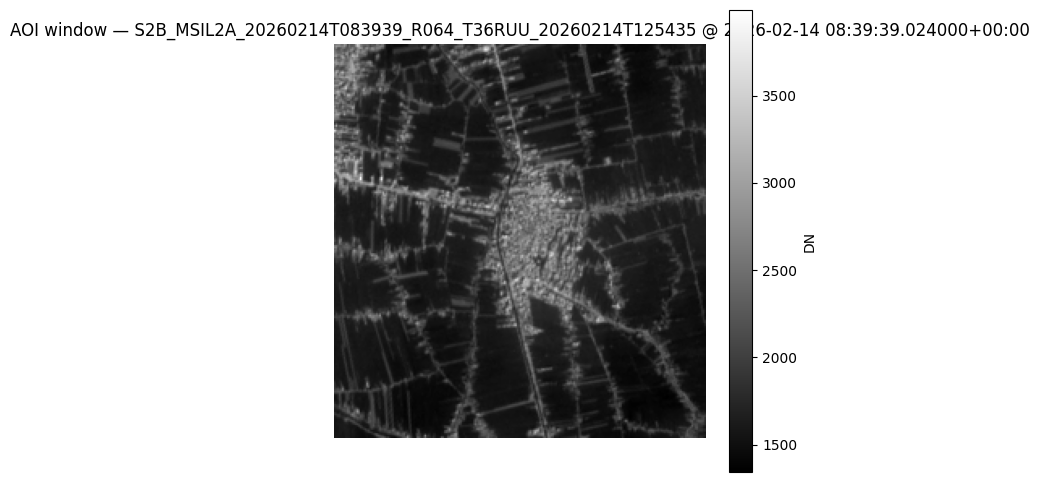

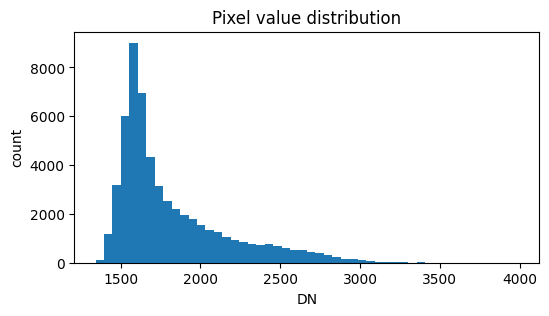

In [92]:
# Plot the AOI window read from the test item
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(test_arr, cmap="gray")
plt.title(f"AOI window — {test_item.id} @ {test_item.datetime}")
plt.colorbar(label="DN")
plt.axis('off')
plt.show()

# Quick histogram of pixel values
plt.figure(figsize=(6,3))
vals = test_arr.flatten()
vals = vals[~np.isnan(vals)] if np.isnan(vals).any() else vals
plt.hist(vals, bins=50, color='C0')
plt.title('Pixel value distribution')
plt.xlabel('DN')
plt.ylabel('count')
plt.show()

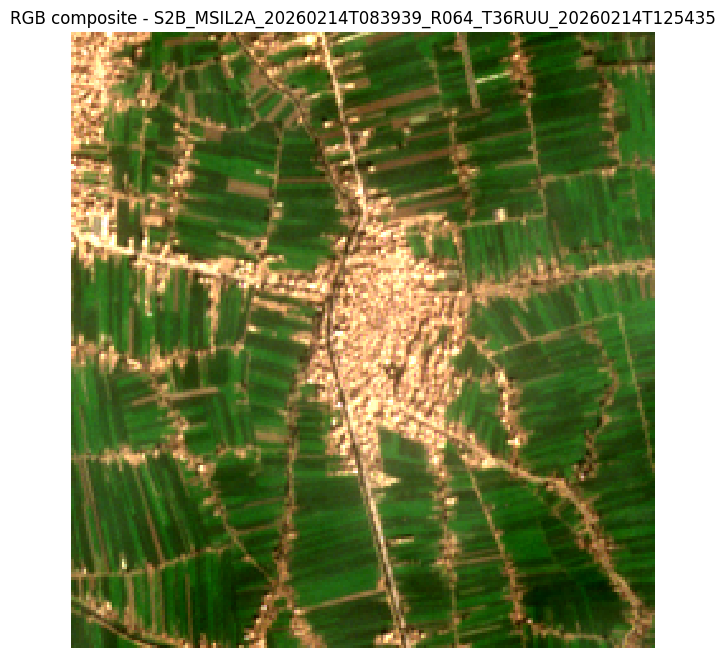

In [97]:
# Read RGB bands
sign_item_inplace(test_item)
b04, _, _ = read_bbox_window(test_item.assets["B04"].href, bbox, dst_resampling=Resampling.bilinear)  # Red
b03, _, _ = read_bbox_window(test_item.assets["B03"].href, bbox, dst_resampling=Resampling.bilinear)  # Green
b02, _, _ = read_bbox_window(test_item.assets["B02"].href, bbox, dst_resampling=Resampling.bilinear)  # Blue

# Stack and normalize for display
rgb = np.dstack([b04, b03, b02])
# Use percentile-based normalization for better contrast
p2, p98 = np.percentile(rgb[~np.isnan(rgb)], (2, 98))
rgb_norm = np.clip((rgb - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(8,8), dpi=100)  # Larger display
plt.imshow(rgb_norm, interpolation='nearest')  # No matplotlib interpolation
plt.title(f"RGB composite - {test_item.id}")
plt.axis('off')
plt.show()

![image-7.png](assets/image.png)
## Summary

**The code is working perfectly.** The visual quality difference has nothing to do with your implementation.

**The Issue:**
- **Sentinel-2 data**: 10 meters/pixel resolution (free, public)
- **Reference map (Google Maps)**: 15-50 cm/pixel resolution (commercial satellites like Maxar, aerial photography)
- **That's 20-66× higher resolution** in the reference map

**Reality Check:**
The diagnostic shows you're getting exactly the right data:
- 243 × 230 pixels for a 2.3km × 2.4km area
- 10m/pixel resolution ✓
- Correct window reads ✓
- Proper CRS transformations ✓